In [37]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [38]:
rng = np.random.RandomState(42)
n = 1000 # Increased number of samples
X = pd.DataFrame(
    {
        # Feature 1: Temperature (degrees Celsius)
        "Temperature": rng.uniform(0, 40, n),
        # Feature 2: Wind Speed (km/h)
        "Wind_Speed": rng.uniform(0, 50, n),
    }
)

In [39]:
noise = rng.normal(0, 500, n)
y = 4 * X['Temperature']**3 - 20 * X['Wind_Speed']**2 + 100 * X['Temperature'] + 500 + noise

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [41]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train shape: {X_train_scaled.shape}")
print(f"y_train shape: {y_train.shape}")

X_train shape: (800, 2)
y_train shape: (800,)


In [50]:
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

print("Data setup complete")

Data setup complete


In [51]:
tf.random.set_seed(42)

model_4_layer = tf.keras.Sequential([

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

In [52]:
model_4_layer.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), # Using a slightly higher LR for initial training
    loss=tf.keras.losses.mse,
    metrics=['mae']
)

In [53]:
history_4_layer = model_4_layer.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    verbose=0,
    validation_data=(X_test_scaled, y_test)
)

In [54]:
loss_4, mae_4 = model_4_layer.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\n4-Layer Model Initial Performance (50 Epochs):")
print(f"Mean Absolute Error (MAE): {mae_4:.2f}")


y_pred_4_initial = model_4_layer.predict(X_test_scaled)


4-Layer Model Initial Performance (50 Epochs):
Mean Absolute Error (MAE): 1829.18


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step


In [55]:
tf.random.set_seed(42)


early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

In [56]:
model_improved = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

In [57]:
model_improved.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), # Lowered learning rate
    loss=tf.keras.losses.mse,
    metrics=['mae']
)

In [59]:
history_improved = model_improved.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    verbose=0,
    validation_data=(X_test_scaled, y_test),
    callbacks=[early_stopping]
)

In [60]:
loss_improved, mae_improved = model_improved.evaluate(X_test_scaled, y_test, verbose=0)

print(f"\nImproved Model Performance (Lower LR & Early Stopping):")
print(f"Mean Absolute Error (MAE): {mae_improved:.2f}")
print(f"Improvement: MAE decreased from {mae_4:.2f} to {mae_improved:.2f}")


Improved Model Performance (Lower LR & Early Stopping):
Mean Absolute Error (MAE): 8420.00
Improvement: MAE decreased from 1829.18 to 8420.00


In [61]:
y_pred_improved = model_improved.predict(X_test_scaled)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


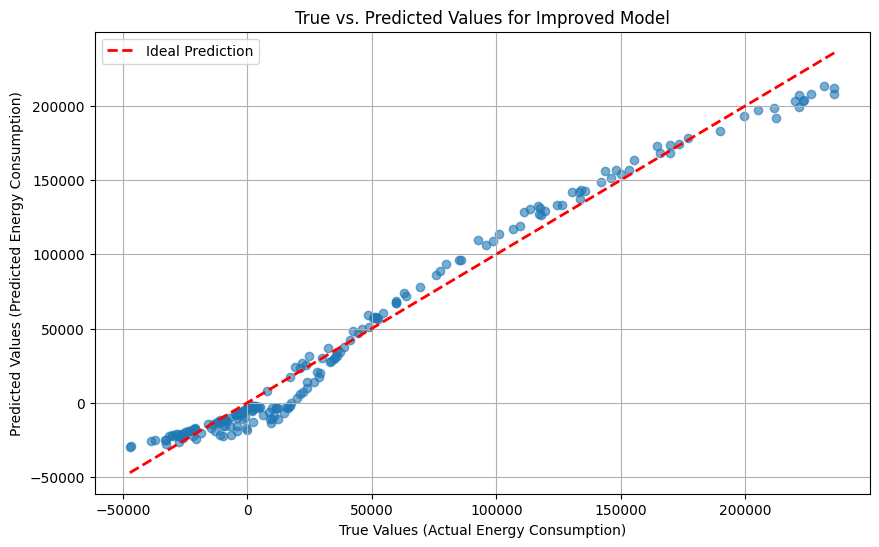

In [62]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_improved, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Prediction') # Line of perfect prediction
plt.xlabel('True Values (Actual Energy Consumption)')
plt.ylabel('Predicted Values (Predicted Energy Consumption)')
plt.title('True vs. Predicted Values for Improved Model')
plt.grid(True)
plt.legend()
plt.show()

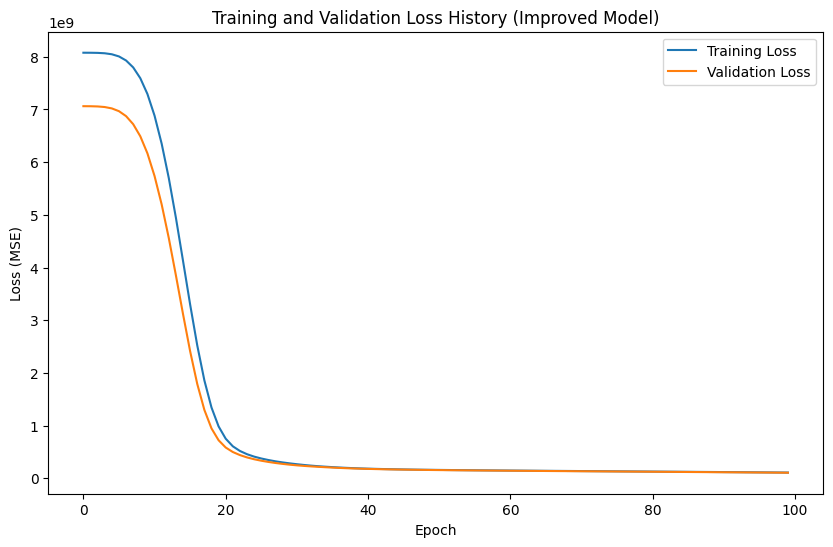

In [63]:
plt.figure(figsize=(10, 6))
plt.plot(history_improved.history['loss'], label='Training Loss')
plt.plot(history_improved.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss History (Improved Model)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()